# hierarchical bayes using NDE --- Test 0
Test 0 is on a noiseless dataset, which simplifies the inference framework

In [1]:
import numpy as np

In [2]:
import torch
from sbi.inference import NPE

In [3]:
import corner as DFM
import matplotlib.pyplot as plt

In [4]:
params = np.load("/Users/chang/data/px2cosmo/test0/mock0_N100000fdown10.params.npy")[::100]
data = np.load("/Users/chang/data/px2cosmo/test0/mock0_N100000fdown10.data.npy")[::100]

In [5]:
print(params.shape[0])

2199604


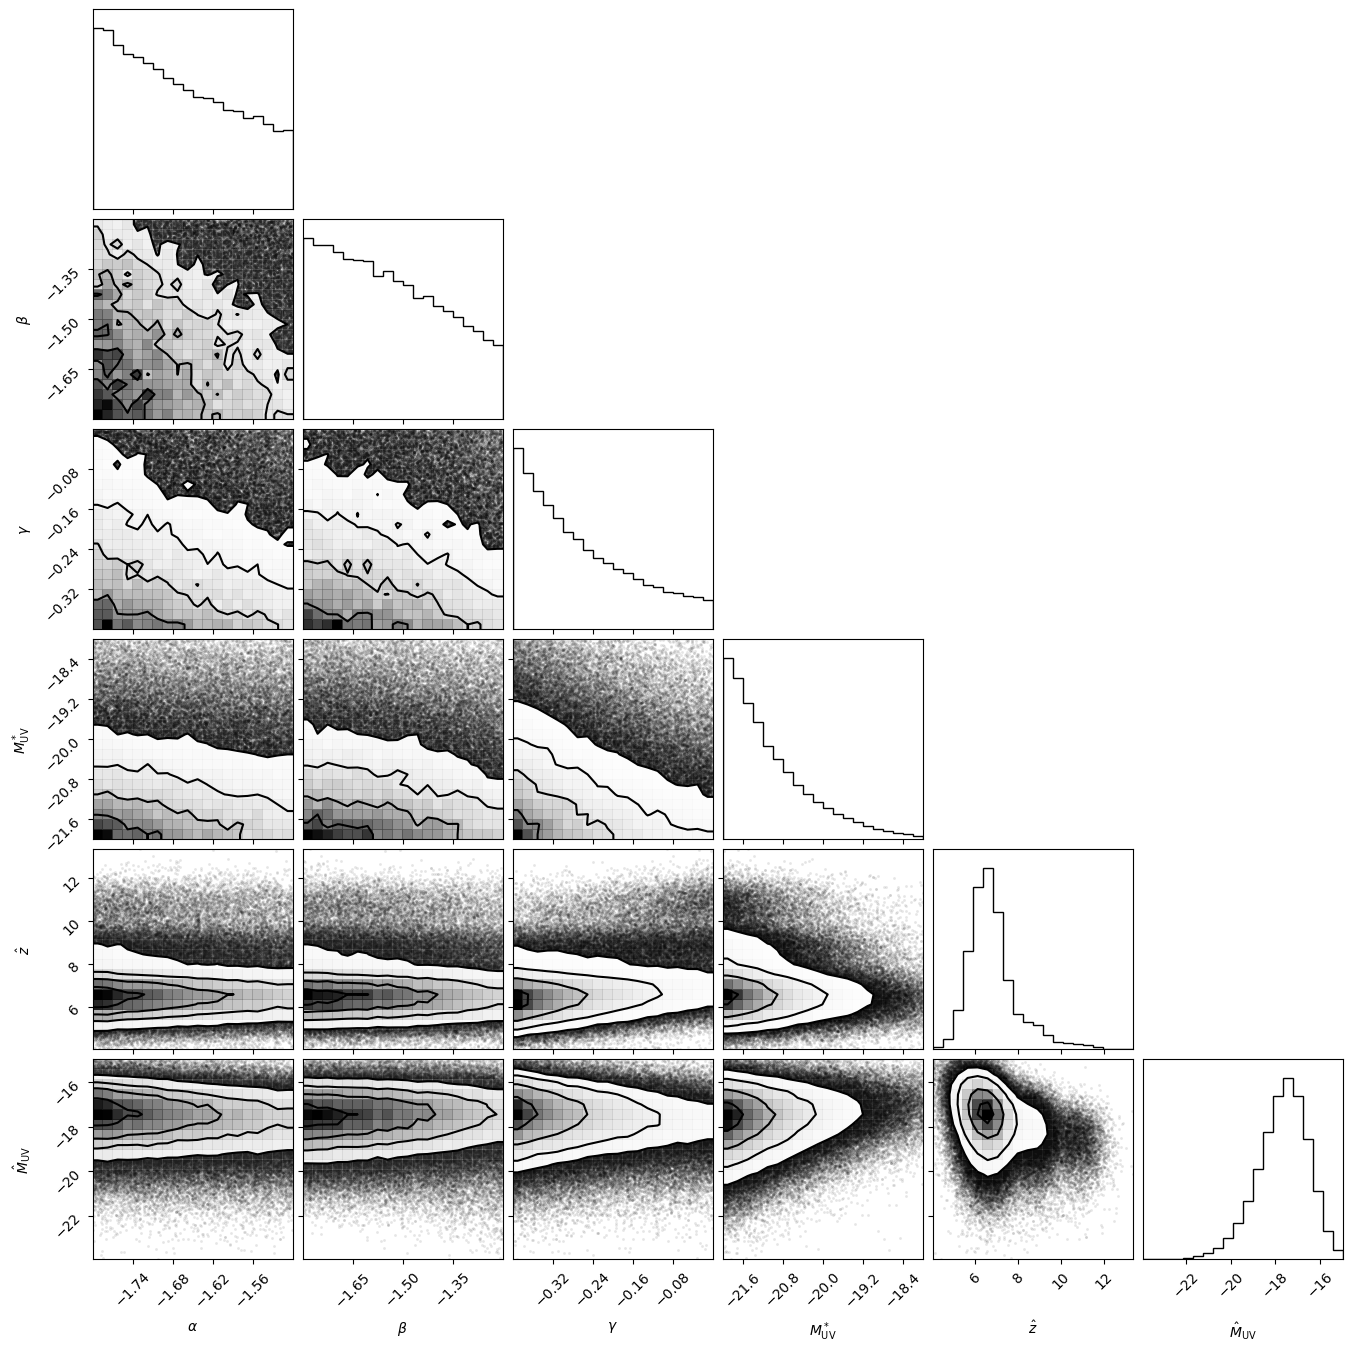

In [6]:
fig = DFM.corner(np.hstack([params, data])[::10], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\hat{z}$', r'$\hat{M}_{\rm UV}$'])

## train NDE

We want to estimate $p(X\,|\,\phi)$

In [7]:
ishuffle = np.arange(params.shape[0])
np.random.shuffle(ishuffle)

In [8]:
_phi = torch.tensor(params[ishuffle][:int(params.shape[0]*0.9)].astype(np.float32))#.to('mps')
_X = torch.tensor(data[ishuffle][:int(params.shape[0]*0.9)].astype(np.float32))#.to('mps')

In [9]:
inference = NPE(density_estimator='zuko_nsf')#, device='mps')
_ = inference.append_simulations(_X, _phi).train()

 Neural network successfully converged after 82 epochs.

In [10]:
p_X_phi = inference.build_posterior()

/opt/homebrew/Caskroom/miniconda/base/envs/jwst/lib/python3.14/site-packages/sbi/inference/potentials/posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


## validate NDE

In [22]:
test_phi = torch.tensor(params[ishuffle][int(params.shape[0]*0.9):][::10].astype(np.float32))#.to('mps')
test_X = torch.tensor(data[ishuffle][int(params.shape[0]*0.9):][::10].astype(np.float32))#.to('mps')

  0%|          | 0/10000 [00:00<?, ?it/s]

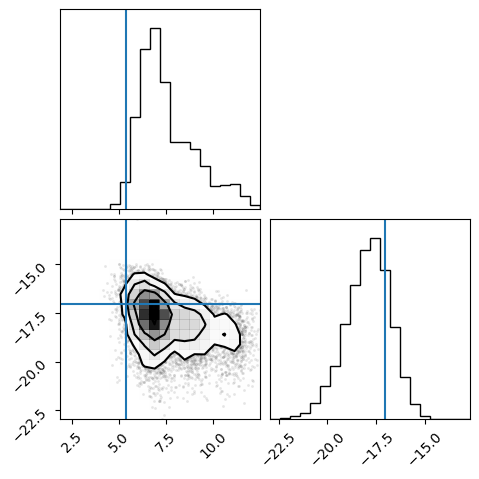

  0%|          | 0/10000 [00:00<?, ?it/s]

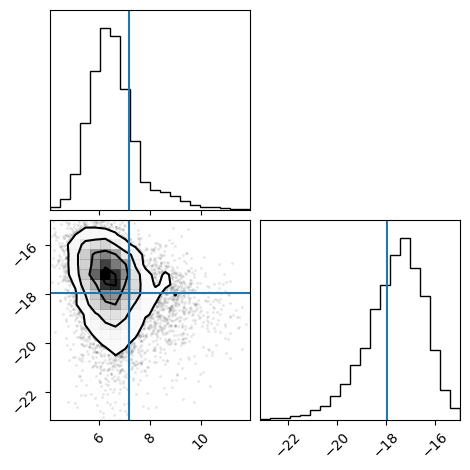

  0%|          | 0/10000 [00:00<?, ?it/s]

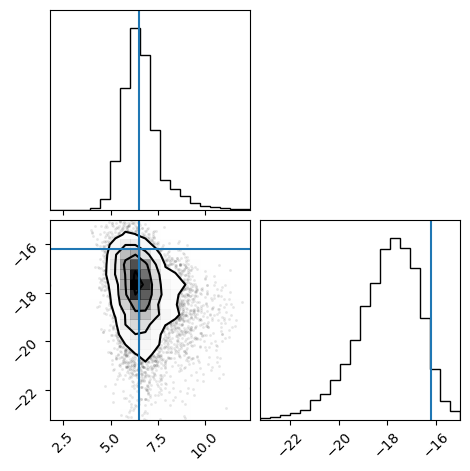

In [15]:
for i in range(3):
    samples = p_X_phi.sample((10000,), x=test_phi[i]).cpu()
    fig = DFM.corner(samples.numpy())
    DFM.overplot_lines(fig, test_X[i].cpu())
    plt.show()

In [16]:
test_samples = p_X_phi.sample_batched((1000,), x=test_phi, show_progress_bars=False)

/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_23024/2729307748.py:1: UserWarning: Note that for batched sampling, the direct posterior sampling generates 2200 * 1000 = 2200000 samples. This can be slow and memory-intensive. Consider reducing the number of samples or batch size.
  test_samples = p_X_phi.sample_batched((1000,), x=test_phi, show_progress_bars=False)
/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_23024/2729307748.py:1: UserWarning: Capping max_sampling_batch_size from 10000 to 45 to avoid excessive memory usage.
  test_samples = p_X_phi.sample_batched((1000,), x=test_phi, show_progress_bars=False)


In [17]:
import tarp

In [18]:
ecp, alpha = tarp.get_tarp_coverage(test_samples.cpu().numpy(), test_X.cpu().numpy())

Text(0.5, 0, 'Credibility Level')

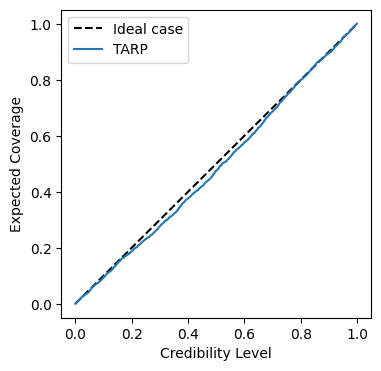

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot([0, 1], [0, 1], ls='--', color='k', label = "Ideal case")
ax.plot(alpha, ecp, label='TARP')
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")

In [18]:
#torch.save(p_X_phi, '/Users/chang/data/px2cosmo/test0/mock0_p_X_phi.pt')

# additional tests of the likelihood

In [23]:
from px2cosmo import fm as FM 
from px2cosmo import util as UT

In [24]:
phi_true = np.array([-1.65, -1.5, -0.2, -19.5]) # fit by eye to zeus21 output

# sample LF 
X_obs = FM.forwardmodel(phi_true, name='test0')

In [26]:
samples = p_X_phi.sample((10000,), x=torch.tensor(phi_true.astype(np.float32))).cpu()

  0%|          | 0/10000 [00:00<?, ?it/s]

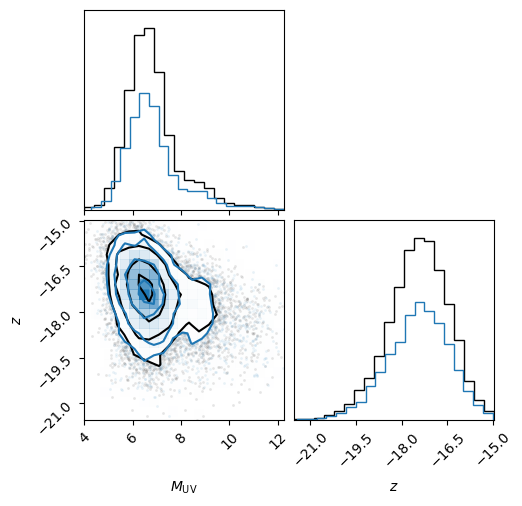

In [27]:
fig = DFM.corner(samples.numpy(), labels=[r"$M_{\rm UV}$", "$z$"])
_ = DFM.corner(X_obs, labels=[r"$M_{\rm UV}$", "$z$"], fig=fig, color='C0')
#DFM.overplot_points(fig, X_obs, markersize=1)

  0%|          | 0/10000 [00:00<?, ?it/s]

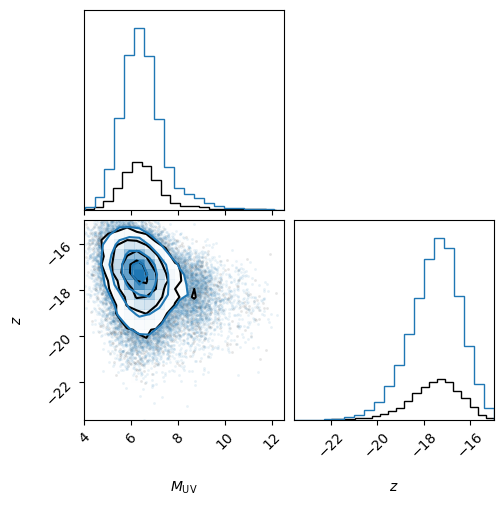

  0%|          | 0/10000 [00:00<?, ?it/s]

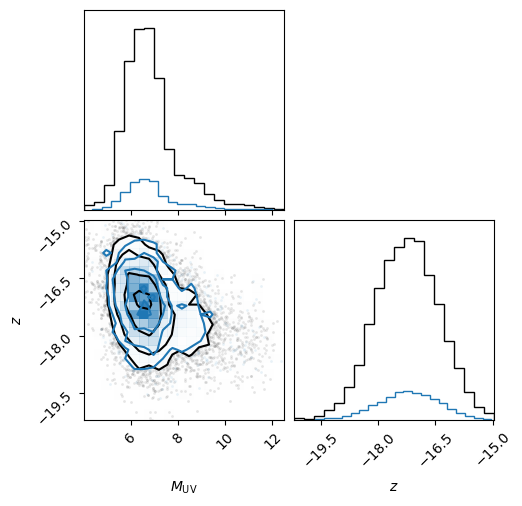

  0%|          | 0/10000 [00:00<?, ?it/s]

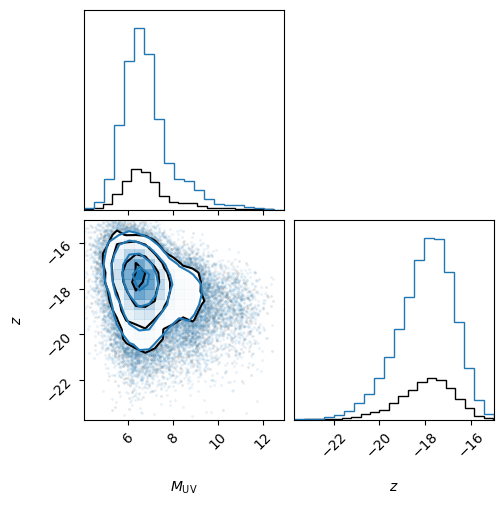

  0%|          | 0/10000 [00:00<?, ?it/s]

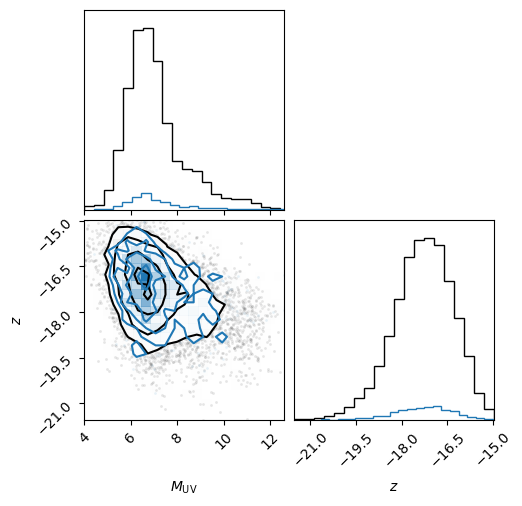

  0%|          | 0/10000 [00:00<?, ?it/s]

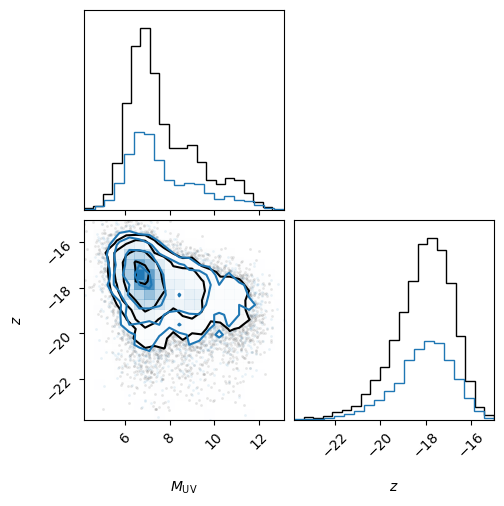

  0%|          | 0/10000 [00:00<?, ?it/s]

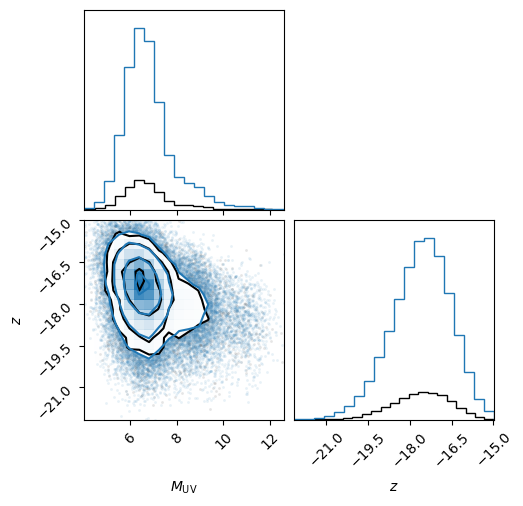

  0%|          | 0/10000 [00:00<?, ?it/s]

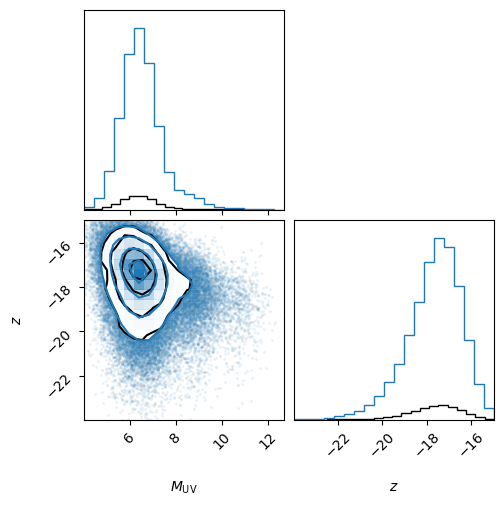

  0%|          | 0/10000 [00:00<?, ?it/s]

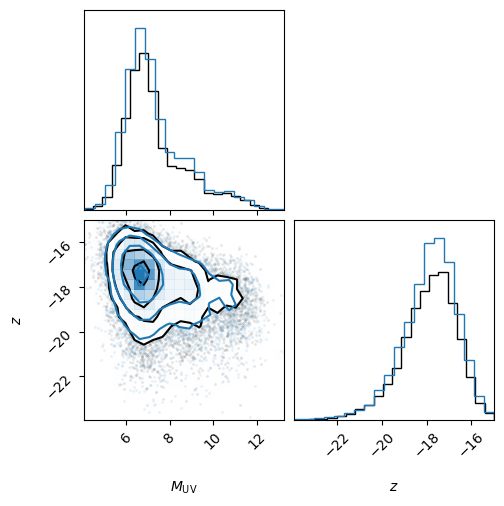

  0%|          | 0/10000 [00:00<?, ?it/s]

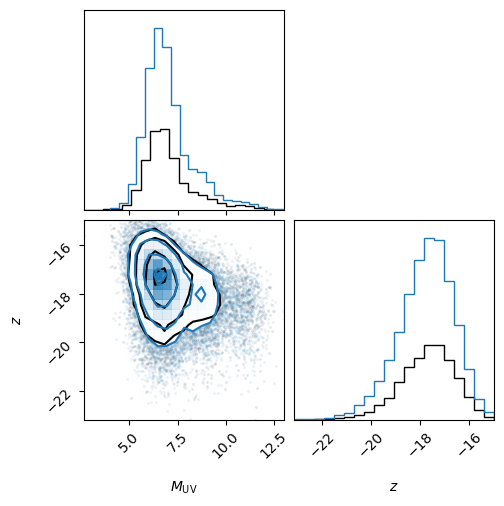

  0%|          | 0/10000 [00:00<?, ?it/s]

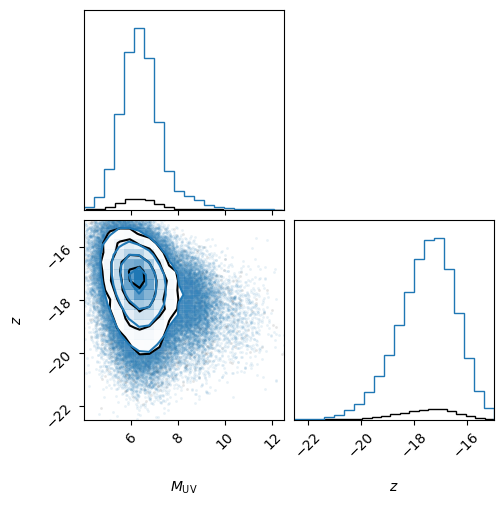

In [29]:
for i in range(10): 
    _alpha = np.random.uniform(-1.8, -1.5) 
    _beta = np.random.uniform(-1.8, -1.2)
    _gamma = np.random.uniform(-0.4, 0.0) 
    _Muv_s = np.random.uniform(-22., -18.)
    _phi = np.array([_alpha, _beta, _gamma, _Muv_s])

    _X = FM.forwardmodel(_phi, name='test0')

    samples = p_X_phi.sample((10000,), x=torch.tensor(_phi.astype(np.float32))).cpu()
    fig = DFM.corner(samples.numpy(), labels=[r"$M_{\rm UV}$", "$z$"])
    _ = DFM.corner(_X, labels=[r"$M_{\rm UV}$", "$z$"], fig=fig, color='C0')
    plt.show()

# likelihood for counts

In [116]:
params_counts = np.load("/Users/chang/data/px2cosmo/test0/mock0_N10000.counts_params.npy")
counts = np.load("/Users/chang/data/px2cosmo/test0/mock0_N10000.counts.npy")

In [139]:
params_counts.shape

(10000, 4)

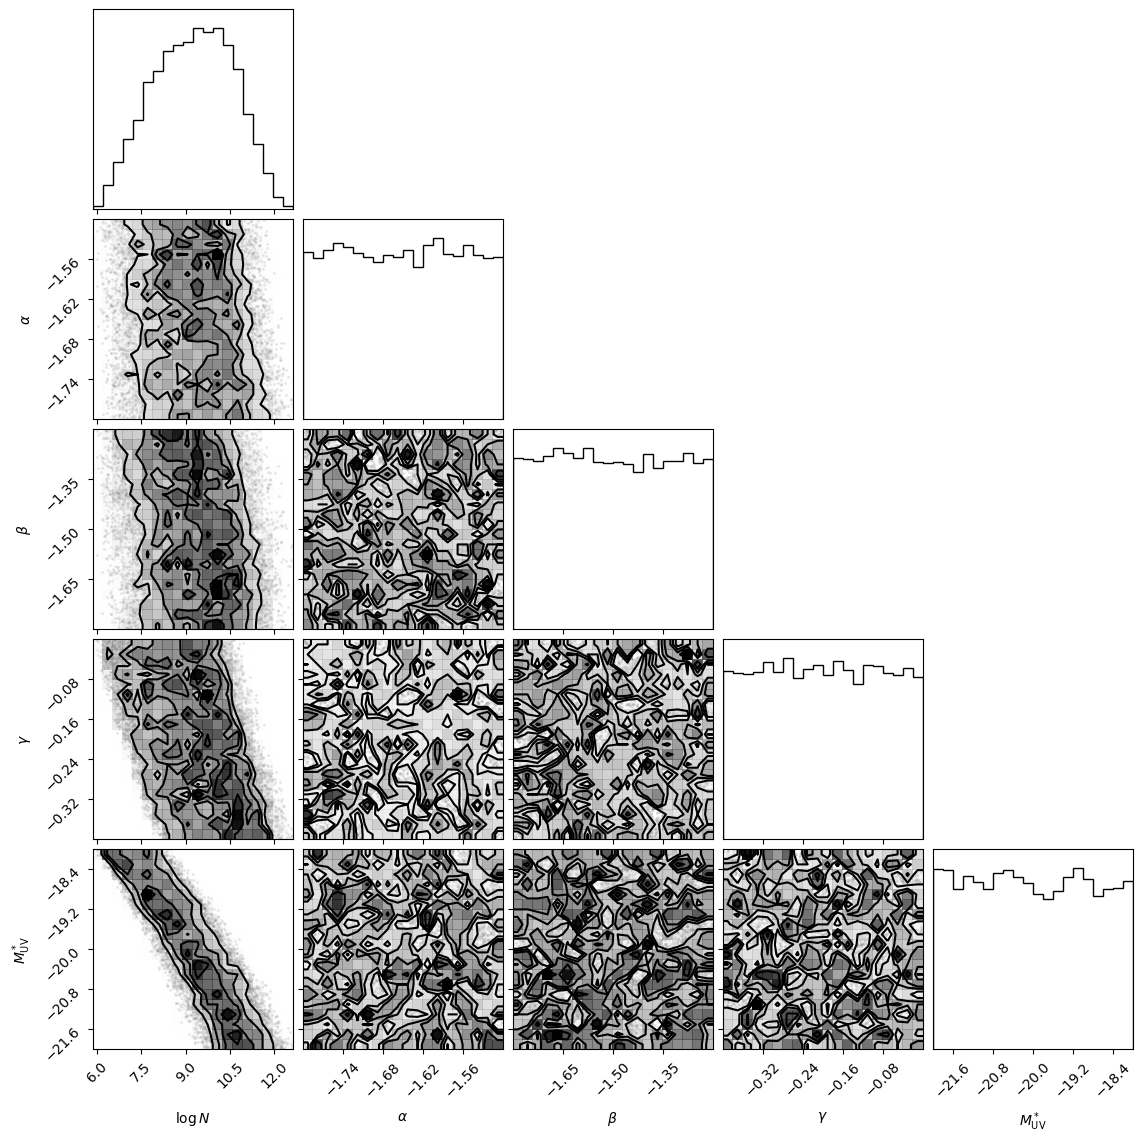

In [117]:
fig = DFM.corner(np.hstack([np.log(counts)[:,None], params_counts]), 
                 labels=[r'$\log N$', r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'])

In [126]:
_ishuffle = np.arange(params_counts.shape[0])
np.random.shuffle(_ishuffle)

In [127]:
__phi = torch.tensor(params_counts[_ishuffle][:int(counts.shape[0]*0.9)].astype(np.float32))#.to('mps')
_logcounts = torch.tensor(np.log(counts)[_ishuffle][:int(counts.shape[0]*0.9)].astype(np.float32)[:,None])#.to('mps')

In [132]:
inference_count = NPE(density_estimator='maf')#, device='mps')
_ = inference_count.append_simulations(_logcounts, __phi).train()

 Neural network successfully converged after 69 epochs.

In [133]:
p_logN_phi = inference_count.build_posterior()

## validate

In [134]:
test__phi = torch.tensor(params_counts[_ishuffle][int(counts.shape[0]*0.9):].astype(np.float32))#.to('mps')
test_logcounts = torch.tensor(np.log(counts)[_ishuffle][int(counts.shape[0]*0.9):].astype(np.float32)[:,None])#.to('mps')

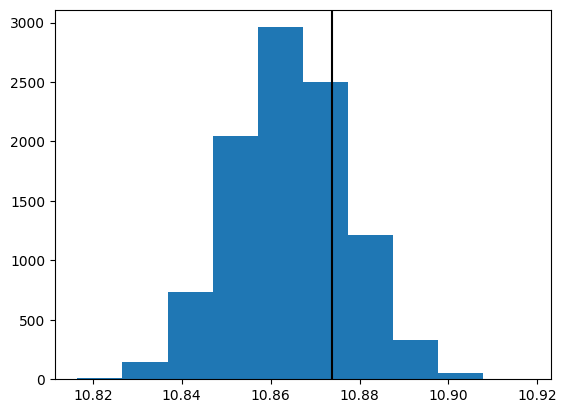

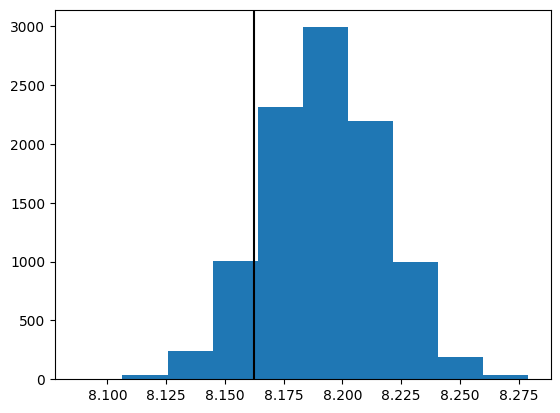

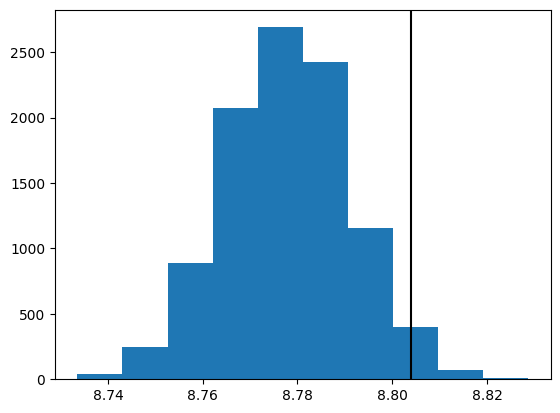

In [135]:
for i in range(3):
    samples = p_logN_phi.sample((10000,), x=test__phi[i], show_progress_bars=False).cpu()
    plt.hist(samples.numpy())
    plt.axvline(test_logcounts[i].cpu(), c='k')
    plt.show()

(array([0.57034221, 0.64038423, 0.75045027, 0.8405043 , 0.99059436,
        1.04062437, 1.27076246, 1.14068441, 1.32079248, 1.44086452]),
 array([1.0000e-04, 1.0004e-01, 1.9998e-01, 2.9992e-01, 3.9986e-01,
        4.9980e-01, 5.9974e-01, 6.9968e-01, 7.9962e-01, 8.9956e-01,
        9.9950e-01]),
 <BarContainer object of 10 artists>)

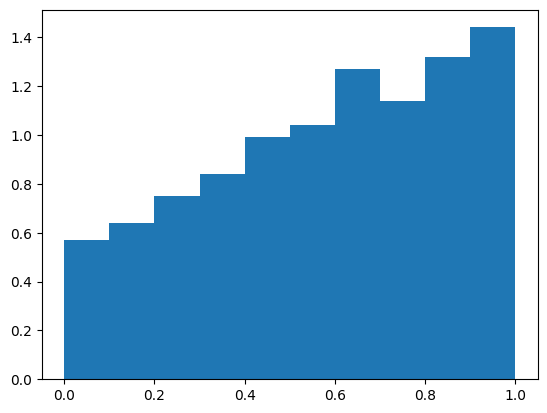

In [140]:
ranks = [] 
for i in range(test__phi.shape[0]):
    samples = p_logN_phi.sample((10000,), x=test__phi[i], show_progress_bars=False).cpu().numpy()
    ranks.append(np.mean(samples < test_logcounts.numpy()[i]))
plt.hist(ranks, density=True)    

# deploy on mock observations

In [30]:
import emcee

In [156]:
def log_prior(phi): 
    alpha, beta, gamma, Muv_s = phi
    if -1.8 < alpha < -1.5 and -1.8 < beta < -1.2 and -0.4 < gamma < 0 and -22 < Muv_s < -18: 
        return 0.
    return -np.inf

In [160]:
_X_obs = torch.tensor(X_obs.astype(np.float32)) #.to('mps')
_logN_obs = torch.tensor(np.log(X_obs.shape[0]).astype(np.float32))

def log_posterior(phi): 
    lp = log_prior(phi)
    if not np.isfinite(lp):
        return -np.inf

    # log likelihood
    _phi = torch.tensor(phi.astype(np.float32)) #.to('mps')
    logp = np.sum(p_X_phi.log_prob_batched(_X_obs, _phi).cpu().numpy())

    # log Poisson
    logp2 = p_logN_phi.log_prob(_logN_obs, _phi).cpu().numpy()
    return logp + logp2

In [161]:
%timeit log_posterior(phi_true)

106 ms ± 1.91 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [158]:
log_posterior(phi_true)

-17968.562 [3.1642754]


array([-17965.398], dtype=float32)

In [159]:
log_posterior(np.median(sampler.flatchain[5000:,:], axis=0))

-17969.723 [-2831.0063]


array([-20800.729], dtype=float32)

In [162]:
ndim, nwalkers = 4, 10
var = np.array([0.1, 0.1, 0.1, 0.1])
p0 = phi_true[None,:] + var[None,:]*np.random.randn(nwalkers, ndim)

In [163]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
_ = sampler.run_mcmc(p0, 1000, progress=True)

  0%|                                                                                                                                                                                  | 0/1000 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniconda/base/envs/jwst/lib/python3.14/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [16:07<00:00,  1.03it/s]


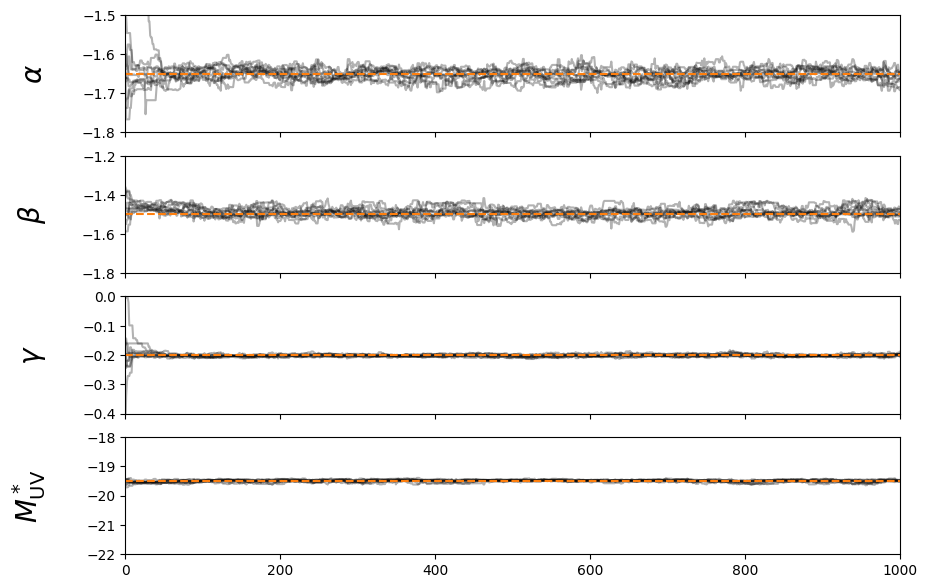

In [164]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [phi_true[i], phi_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim([(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)][i])

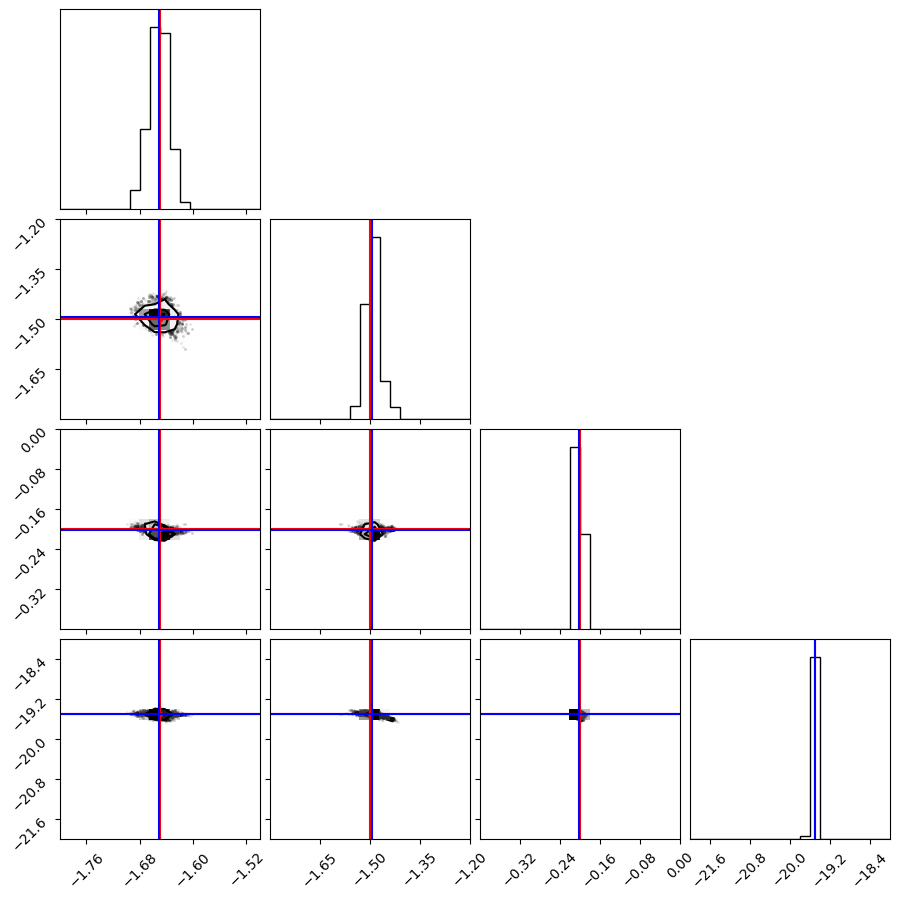

In [165]:
fig = DFM.corner(sampler.flatchain[5000:,:], range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)])
DFM.overplot_points(fig, [phi_true], color='red')
DFM.overplot_lines(fig, phi_true, color='red')
DFM.overplot_lines(fig, np.median(sampler.flatchain[5000:,:], axis=0), color='blue')

In [38]:
log_posterior(phi_true)

np.float32(-17983.277)

In [39]:
log_posterior(np.median(sampler.flatchain[5000:,:], axis=0))

np.float32(-17979.006)

  0%|          | 0/10000 [00:00<?, ?it/s]

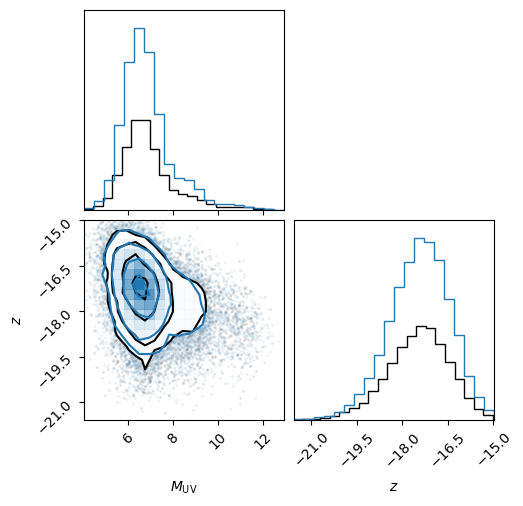

In [43]:
_phi = np.median(sampler.flatchain[5000:,:], axis=0)

_X = FM.forwardmodel(_phi, name='test0')

samples = p_X_phi.sample((10000,), x=torch.tensor(_phi.astype(np.float32))).cpu()
fig = DFM.corner(samples.numpy(), labels=[r"$M_{\rm UV}$", "$z$"])
_ = DFM.corner(_X, labels=[r"$M_{\rm UV}$", "$z$"], fig=fig, color='C0')
plt.show()

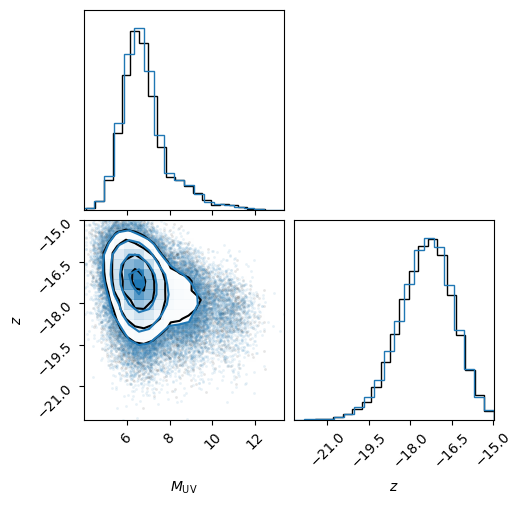

In [66]:
#_phi = np.median(sampler.flatchain[5000:,:], axis=0)

_X = FM.forwardmodel(_phi, name='test0')

#samples = p_X_phi.sample((10000,), x=torch.tensor(_phi.astype(np.float32))).cpu()
fig = DFM.corner(_X, labels=[r"$M_{\rm UV}$", "$z$"], hist_kwargs={"density": True})
_Xs = [] 
for i in range(10): 
    _Xs.append(FM.forwardmodel(phi_true, name='test0'))
_ = DFM.corner(np.vstack(_Xs), labels=[r"$M_{\rm UV}$", "$z$"], fig=fig, color='C0', hist_kwargs={"density": True})
plt.show()

(18209, 2)
(6572, 2)


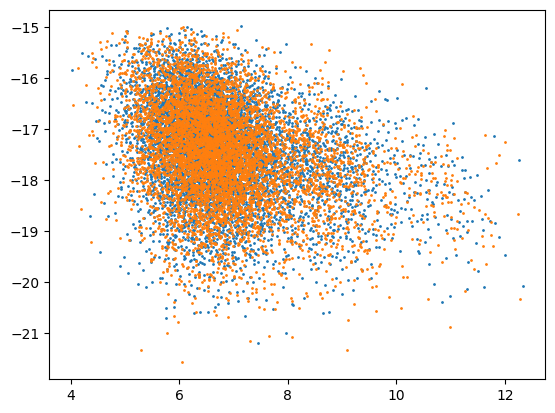

In [57]:
_X = FM.forwardmodel(_phi, name='test0')
print(_X.shape)
plt.scatter(_X[::3,0], _X[::3,1], s=1)
_X = FM.forwardmodel(phi_true, name='test0')
print(_X.shape)
plt.scatter(_X[:,0], _X[:,1], s=1)

In [51]:
logps = p_X_phi.log_prob_batched(_X_obs, torch.tensor(_phi.astype(np.float32))).cpu().numpy()

In [52]:
logps

array([[-6.246752 , -6.694499 , -5.7875433, ..., -7.6817484, -7.7892914,
        -9.179405 ]], shape=(1, 6482), dtype=float32)

In [67]:
# sample LF 
X_obs = []
for i in range(10): 
    X_obs.append(FM.forwardmodel(phi_true, name='test0'))
X_obs = np.vstack(X_obs)

In [68]:
_X_obs = torch.tensor(X_obs.astype(np.float32)) #.to('mps')

def log_posterior(phi): 
    lp = log_prior(phi)
    if not np.isfinite(lp):
        return -np.inf

    # log likelihood
    _phi = torch.tensor(phi.astype(np.float32)) #.to('mps')
    logp = np.sum(p_X_phi.log_prob_batched(_X_obs, _phi).cpu().numpy())

    # evidence 
    
    #if np.isnan(logp): raise ValueError
    return logp

In [69]:
log_posterior(phi_true)

np.float32(-181160.72)

In [70]:
log_posterior(np.median(sampler.flatchain[5000:,:], axis=0))

np.float32(-181140.0)

(2e-05, 0.1)

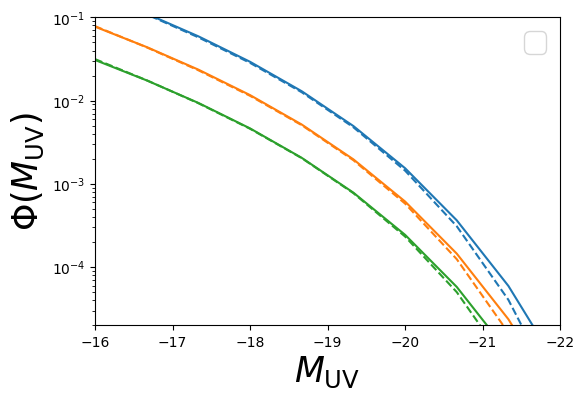

In [79]:
fig = plt.figure(figsize=(6,4))
sub = fig.add_subplot(111)

phi_amp = 6e-3
Muv_bin = np.linspace(-16, -22, 10)
for i, z0 in enumerate([5., 7., 9.]): 
    sub.plot(Muv_bin, phi_amp*UT.LF(Muv_bin, z0, phi_true), c='C%i' % i)
    sub.plot(Muv_bin, 0.35*phi_amp*UT.LF(Muv_bin, z0, np.median(sampler.flatchain[5000:,:], axis=0)), c='C%i' % i, ls='--')

sub.legend(loc='upper right', handletextpad=0.1, fontsize=20)
sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_xlim(-16, -22)
sub.set_yscale('log')
sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
plt.ylim(2e-5, 1e-1)